shape: (79440, 3) | 列: ['date', 'instrument', 'factor']
含 inf: False
每日缺失(=0)率均值: 0.0027
factor 分位: {0.01: -0.9389, 0.25: -0.131, 0.5: 0.0108, 0.75: 0.1469, 0.99: 0.7582}
[2026-07-10 15:48:30] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-10 15:48:31] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-10 15:48:31] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-07-10 15:48:31] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-09-02 至 2024-12-31
[2026-07-10 15:48:31] [info     ] ========== 数据检查 ==========
[2026-07-10 15:48:31] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_a

时段,IC
2024-09-24~2024-10-08,0.0045

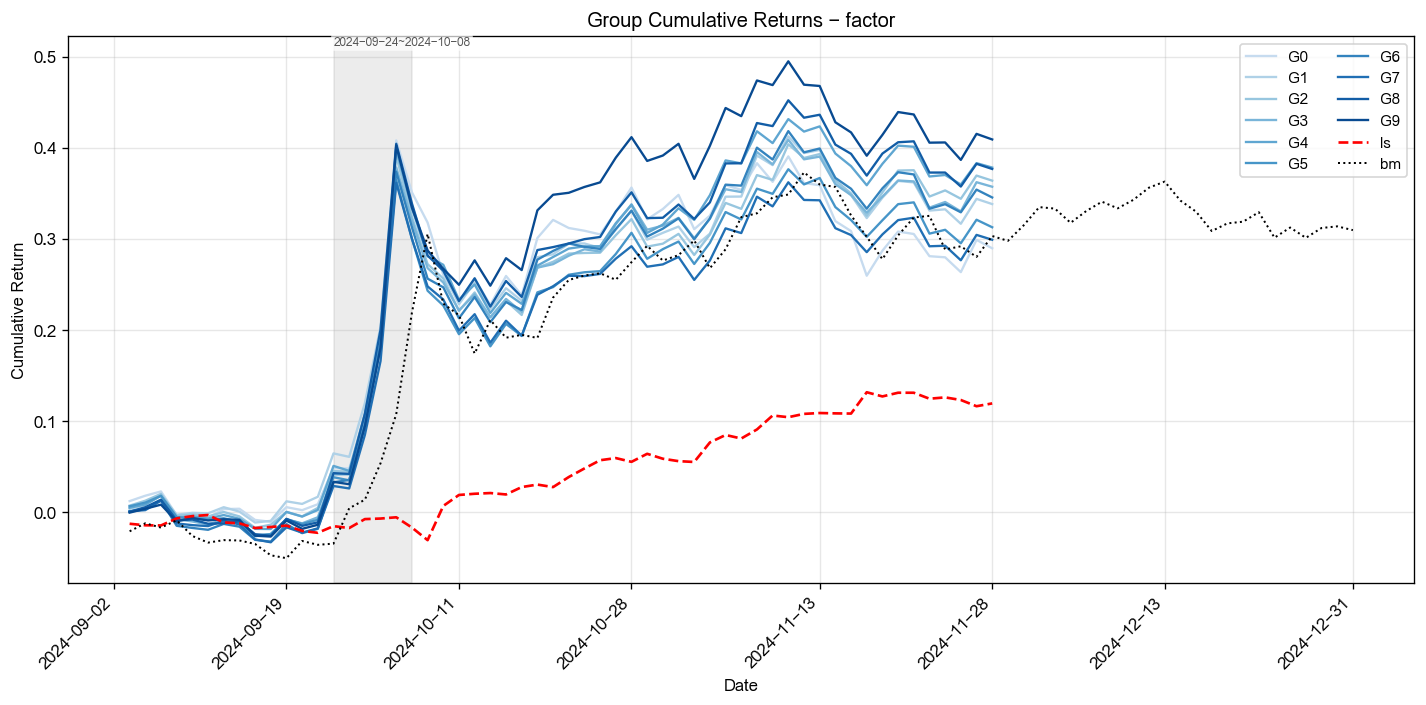
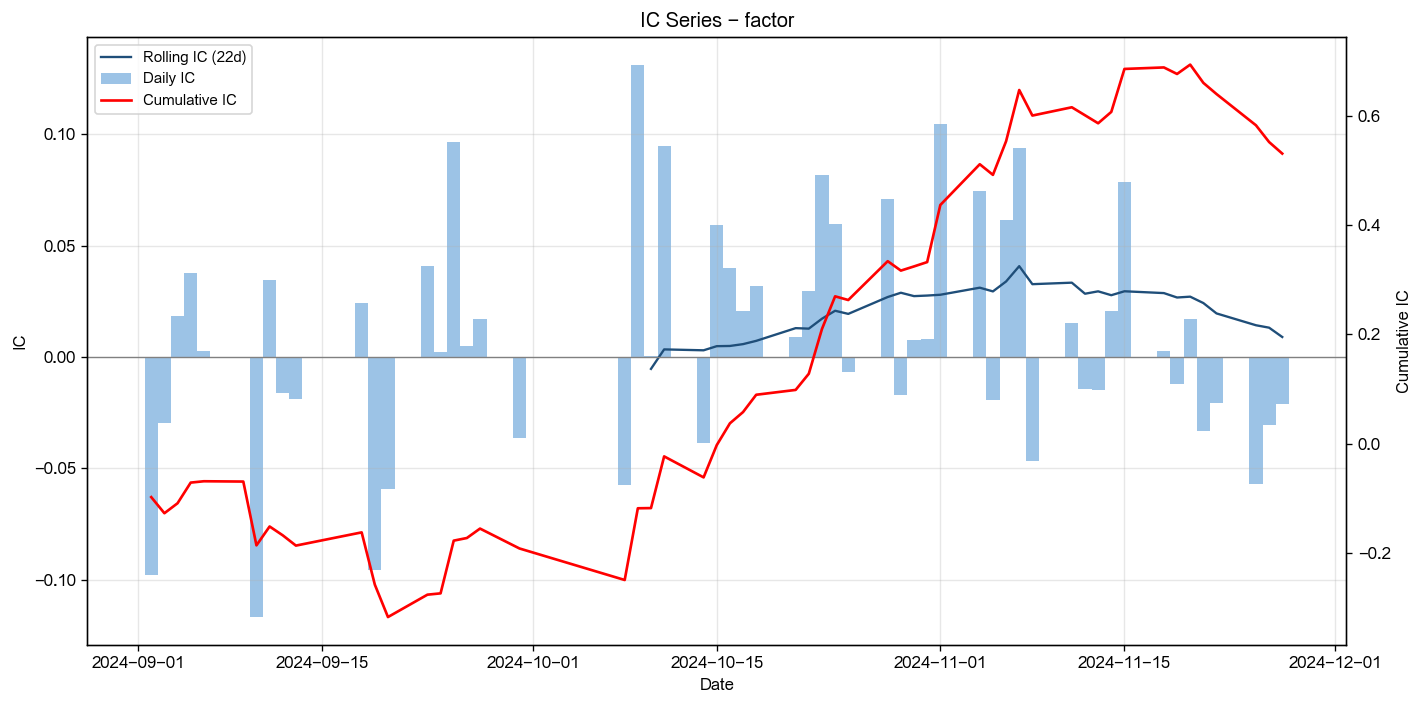
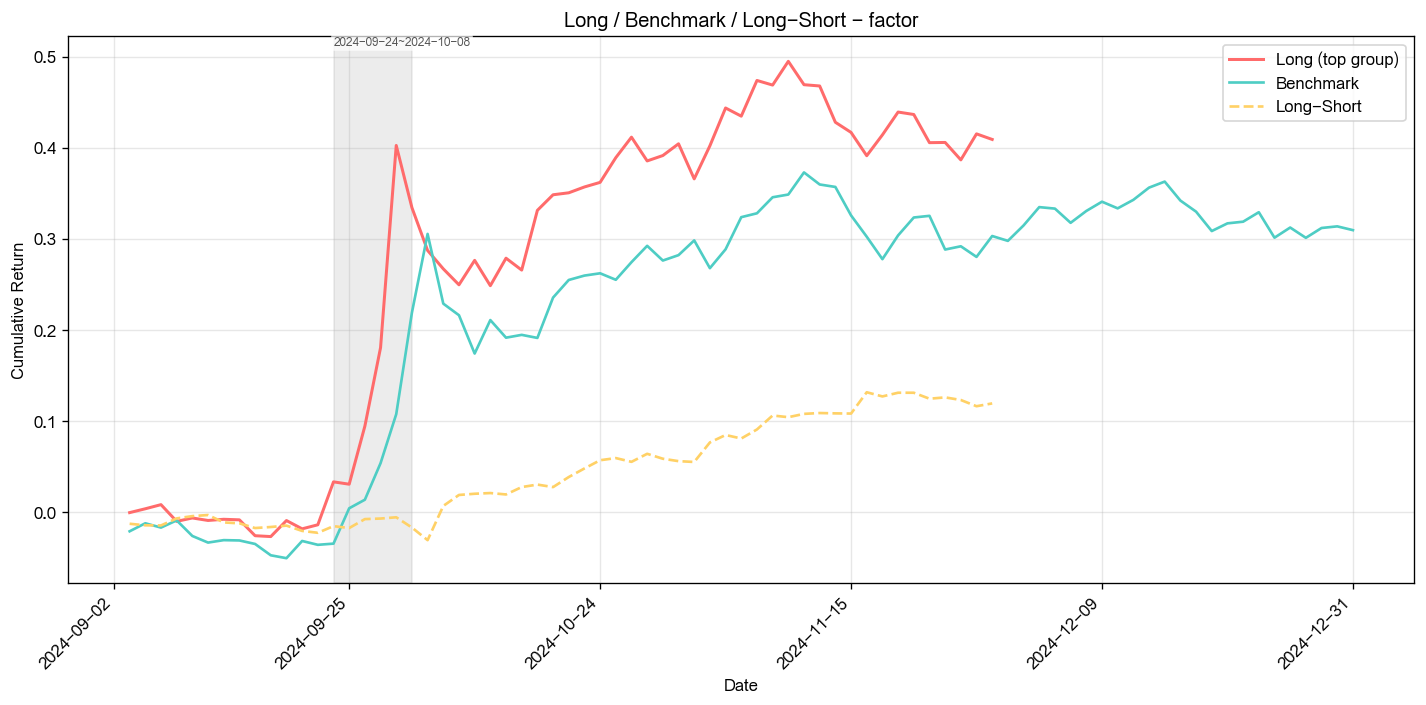
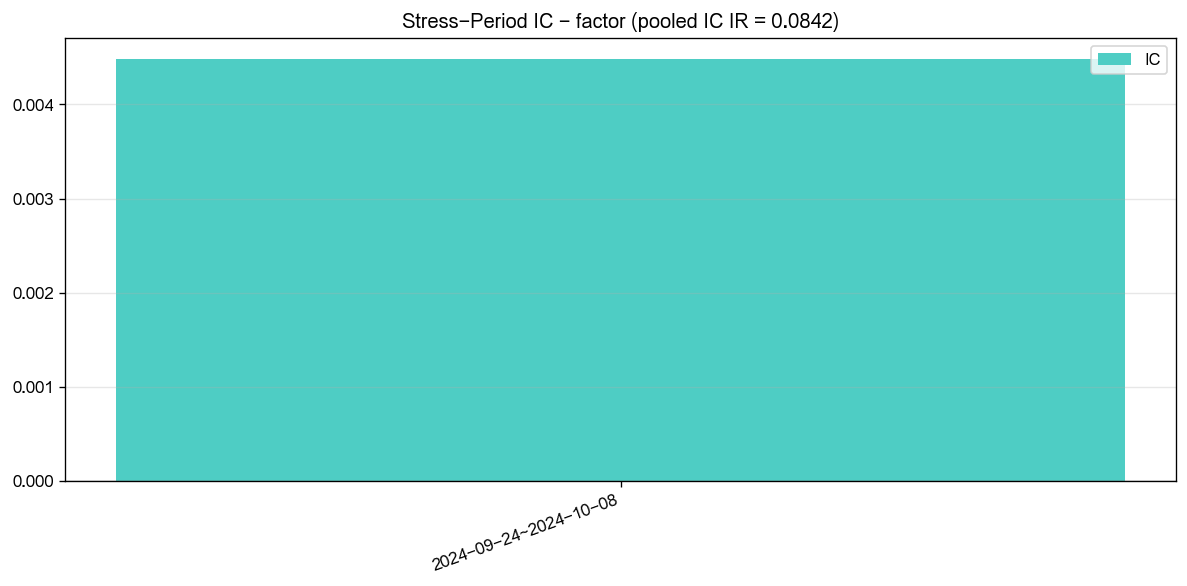
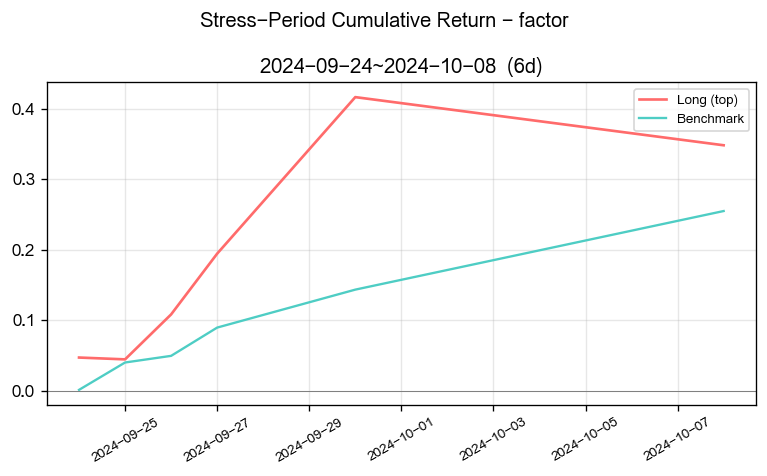

[2026-07-10 15:48:39] [info     ] ========== 因子池回归 ==========
[2026-07-10 15:48:39] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1101 rows=96735 start_date=2024-09-02
[2026-07-10 15:48:39] [info     ] 获取收益率数据, 耗时: 0.3458 秒
[2026-07-10 15:48:39] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.0958 秒
[2026-07-10 15:48:39] [info     ] 统计 回归结果, 耗时: 0.103 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,netflow_amount_rate_main,10.8866,0.0161,0.0015,1.0000
2,pe_ttm,6.6144,0.0061,0.0009,1.0000
3,macd_diff_12_26_9,5.4773,0.0165,0.0030,1.0000
4,netflow_amount_main,4.2211,0.0258,0.0061,1.0000
5,net_active_buy_amount_main,3.8498,0.0265,0.0069,1.0000
6,volatility_5,3.7935,0.0059,0.0015,1.0000
7,float_market_cap,3.6395,0.0078,0.0021,1.0000
8,kdj_d_9_3_3,3.4854,0.0883,0.0253,1.0000
9,bias_20,3.1283,0.0430,0.0138,1.0000
10,cci_14,2.6350,0.0477,0.0181,1.0000

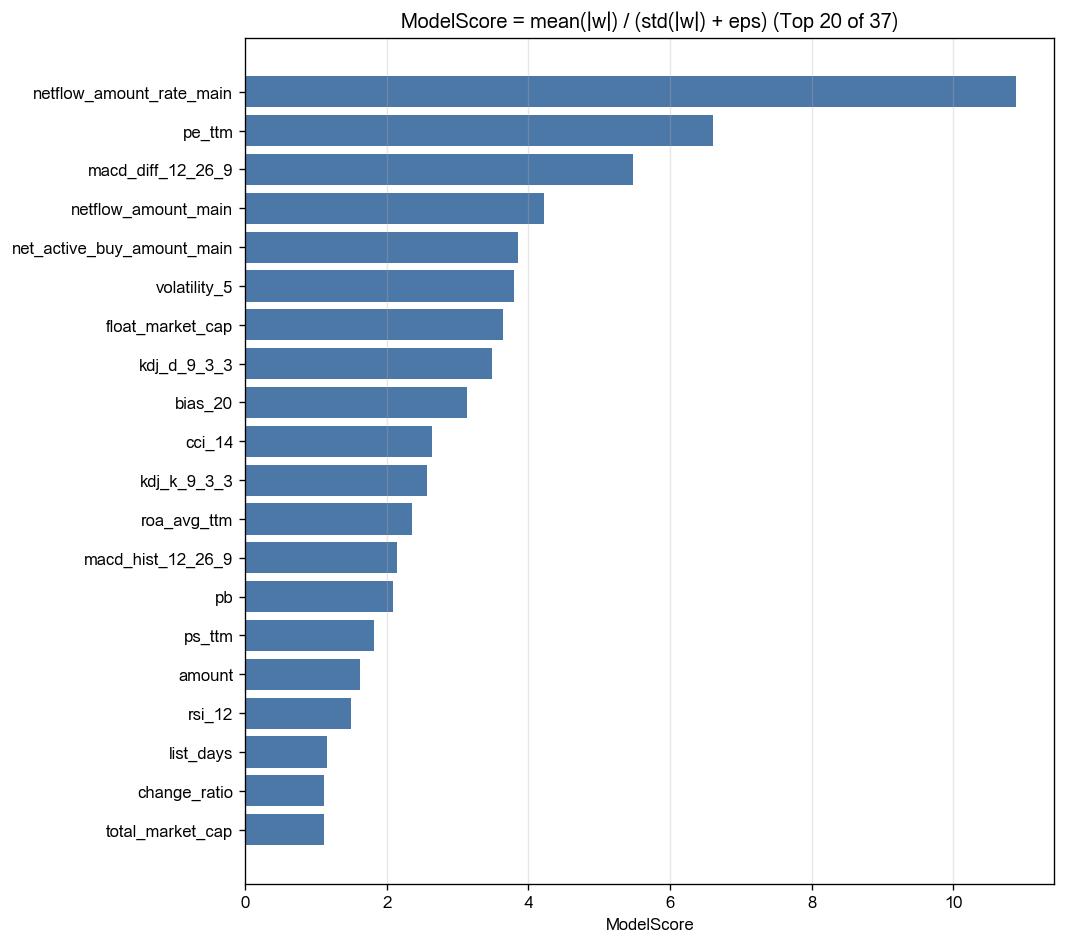
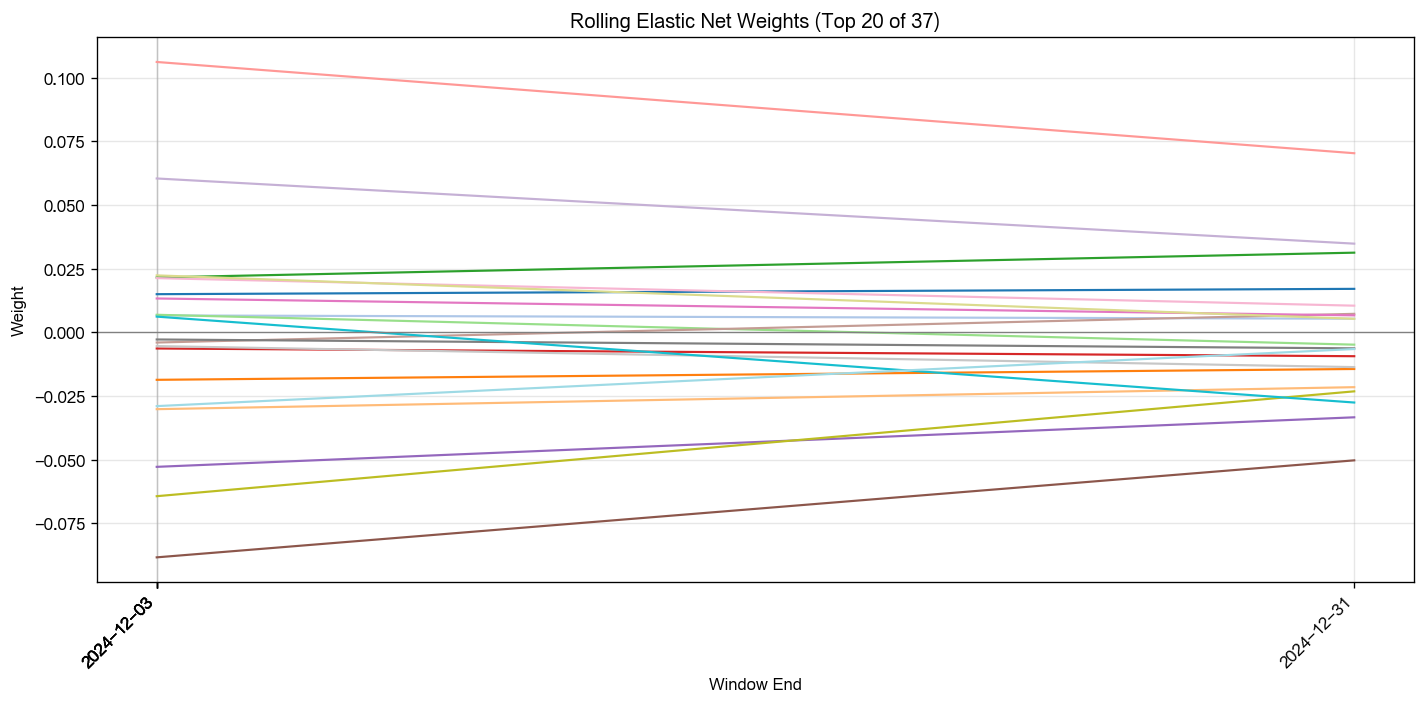
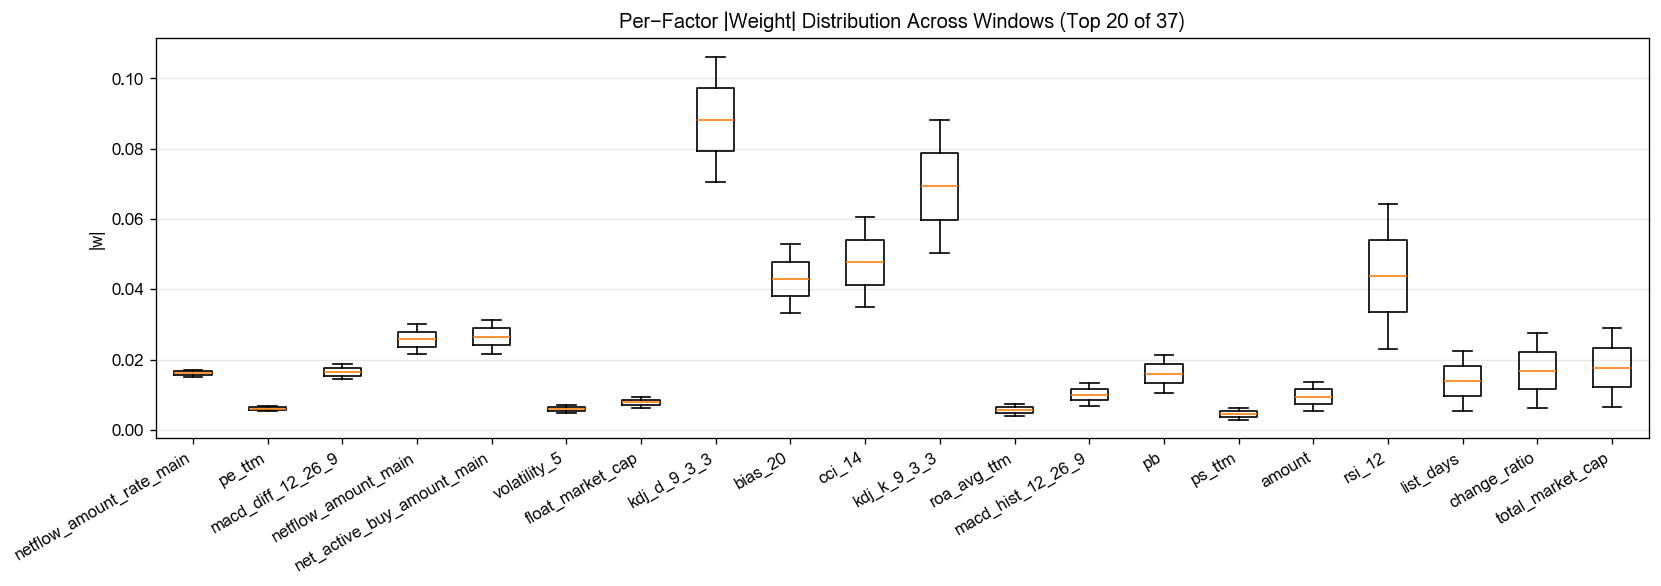
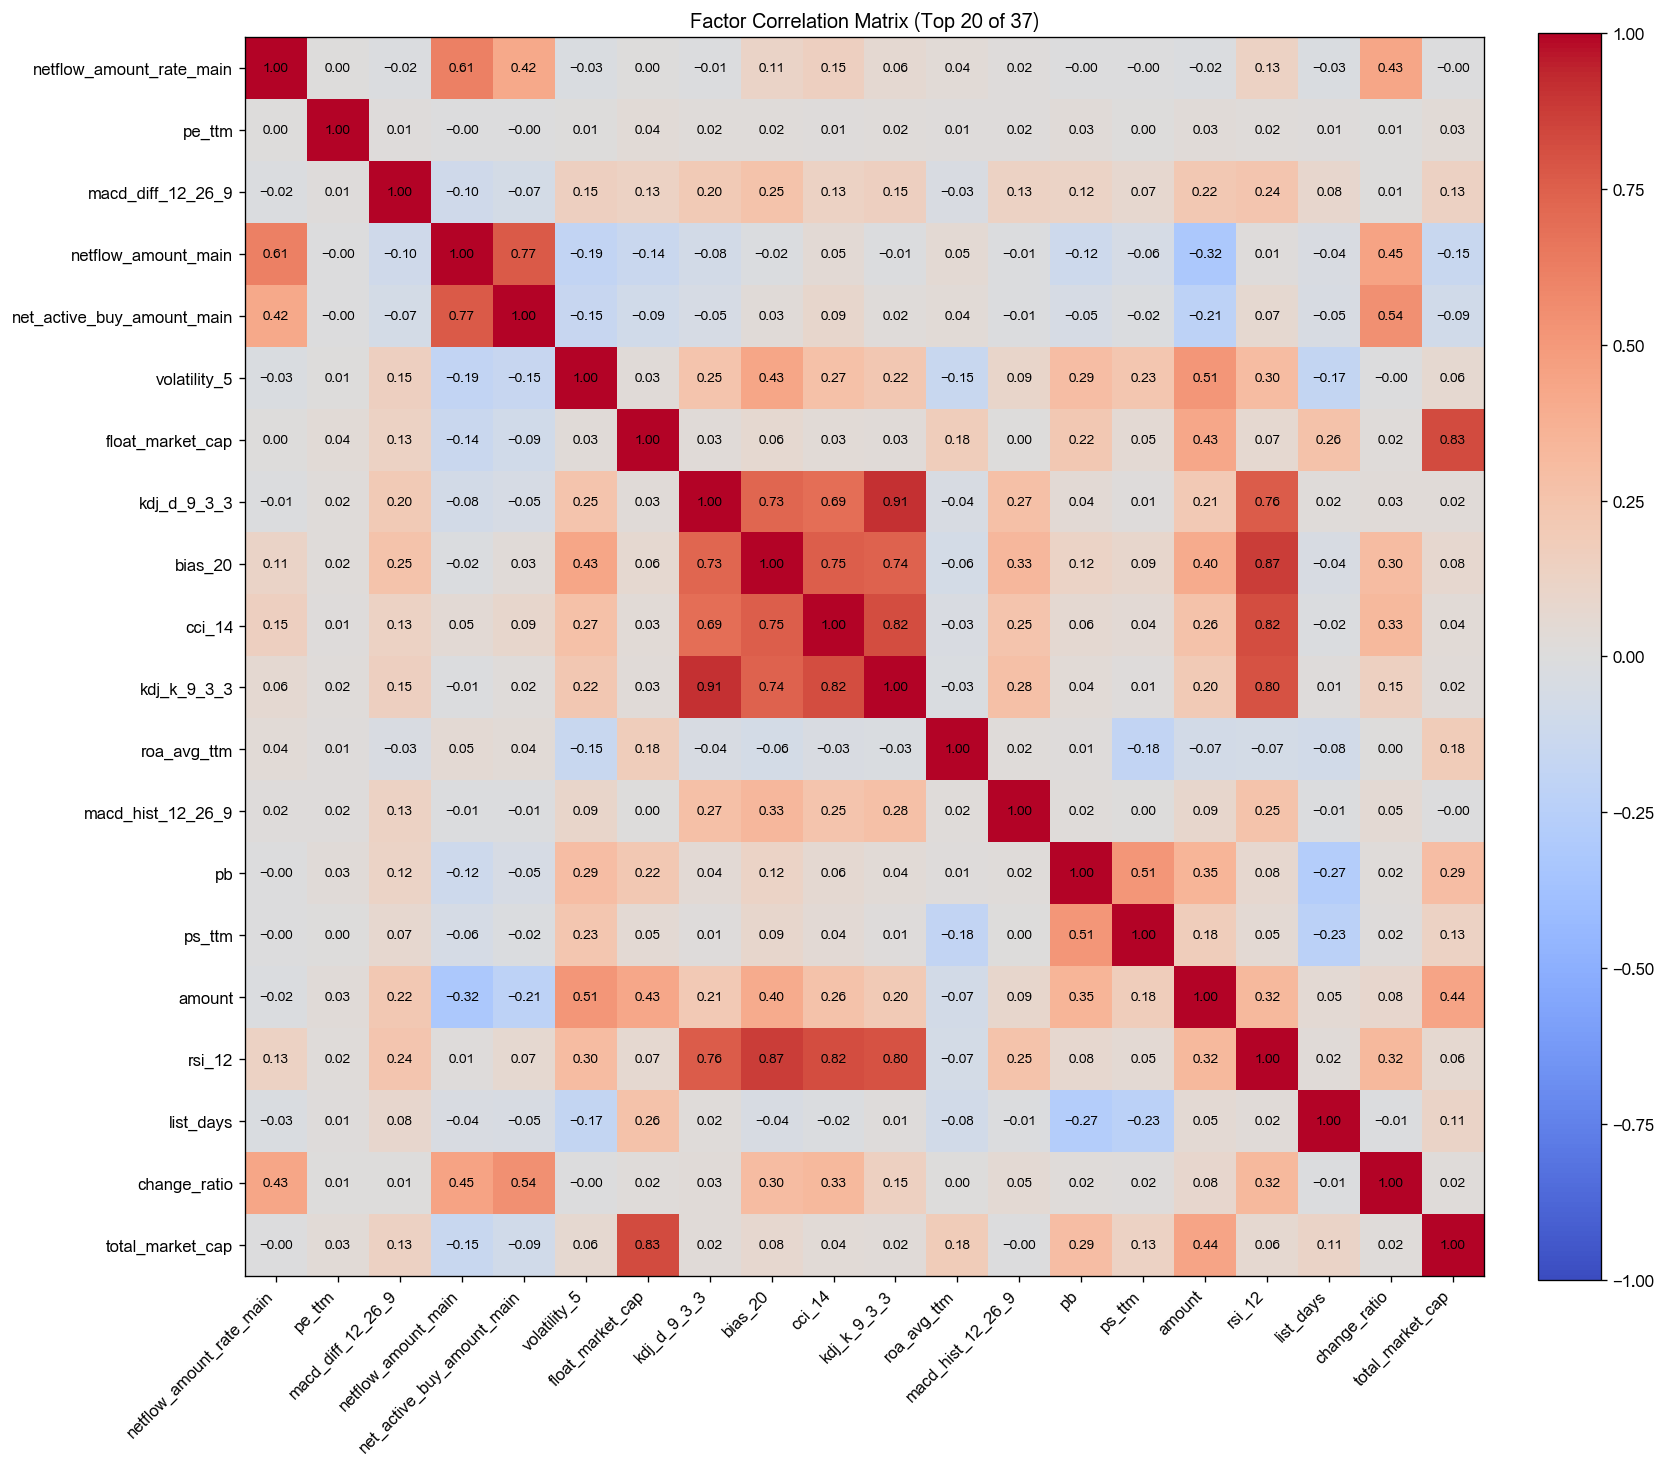

[2026-07-10 15:48:41] [warning  ] 返回的Outputs实例(size=11311797) 大于 64K, 将不会被缓存
[2026-07-10 15:48:41] [info     ] bigalpha_eval.v4 运行完成 [10.049s].


In [1]:
def main(datasources, start_date, end_date):
    """
    因子名称: 同行下行/上行同步不对称 (Intra-Industry Downside/Upside Sync Asymmetry)
    赛道: 传统量化赛道

    经济逻辑(把半beta不对称从"个股vs全市场"搬到"个股vs同行"):
        库里 β_N−β_P(0.780)测个股相对【全市场】的同向共动不对称。本因子换测
        个股相对【同行邻居】的下行/上行同步不对称:
          β_同行⁻ = 同行【下跌】分钟,个股跟跌的强度
          β_同行⁺ = 同行【上涨】分钟,个股跟涨的强度
          因子 = β_同行⁻ − β_同行⁺
            >0: 同行崩时跟着崩、同行涨时不跟 → 板块系统性风险承接者 → 要溢价
            <0: 同行涨时跟涨、跌时抗跌 → 板块内的防御性个股
        作用在【行业层】而非全市场层,BARRA(全市场beta)、β_N−β_P(vs全市场)
        都覆盖不到。与领先-滞后网络(时序因果)同范式但不同关系类型(同期不对称)
        → 天然正交。与共动族(vs等权全市场)不共用市场代理 → 不共命。

    统计方法:
        - 邻居 = 同 industry_level1_code 当日成分(诊断:31行业,中位~30只);
          邻居代理 = 组内【剔除自身】等权分钟收益(自相关污染必剔)。
        - 半beta分解(BLPQ有符号收益,与β_M/β_N−β_P同一套):
          按【同行(邻居)收益符号】分半:
            β⁻ = Σ_{nb<0}(r_i·r_nb) / Σ_{nb<0} r_nb²
            β⁺ = Σ_{nb>0}(r_i·r_nb) / Σ_{nb>0} r_nb²
          (个股在同行下跌/上涨分钟对同行的条件beta,分母同行半方差)
        - 诊断已确认:两侧分钟数中位>110,<30占比0 → 两侧样本充足,无CoM死法。
        - 降维 N×1(每票对1条邻居序列),与β_M同量级;纯日内每天重置,无跨日缓冲。
    数据源: bar1m(close) + exposure(industry_level1_code)
    """
    import numpy as np
    import pandas as pd
    import dai

    SIGN = 1  # 方向自负,提交后按 eval Sharpe 符号定

    bar = datasources["bar1m"]

    # ---- 1. 分钟收盘价 ----
    sql = f"""
        SELECT date, instrument, close AS cls
        FROM {bar}
        WHERE strftime(date, '%H:%M:%S') BETWEEN '09:30:00' AND '15:00:00'
    """
    px = dai.query(sql, filters={'date': [start_date, end_date]},
                   compression=True).df()
    px['instrument'] = px['instrument'].astype(str)
    px['cls'] = pd.to_numeric(px['cls'], errors='coerce')
    px['date'] = pd.to_datetime(px['date'])
    px['d'] = px['date'].dt.normalize()

    # ---- 2. 当日行业码 ----
    exp = dai.query("""
        SELECT date, instrument, industry_level1_code AS ind
        FROM bigalpha_2026_exposure
    """, filters={'date': [start_date, end_date]}, compression=True).df()
    exp['instrument'] = exp['instrument'].astype(str)
    exp['ind'] = exp['ind'].astype(str)
    exp['date'] = pd.to_datetime(exp['date'])
    exp['d'] = exp['date'].dt.normalize()
    exp = exp[['d', 'instrument', 'ind']].drop_duplicates(['d', 'instrument'])

    # ---- 3. 分钟收益 ----
    px = px.sort_values(['instrument', 'date'])
    px['ret'] = px.groupby(['instrument', 'd'])['cls'].transform(
        lambda s: np.log(s) - np.log(s.shift(1)))
    px = px.dropna(subset=['ret']).replace([np.inf, -np.inf], np.nan).dropna(subset=['ret'])
    px = px.merge(exp, on=['d', 'instrument'], how='inner')

    # ---- 4. 逐日逐行业算半beta不对称 ----
    def process_day(day_df):
        wide = day_df.pivot_table(index='date', columns='instrument',
                                  values='ret', aggfunc='first').sort_index()
        ind_map = day_df.drop_duplicates('instrument').set_index('instrument')['ind']

        out = {}
        for ind, members in ind_map.groupby(ind_map).groups.items():
            cols = [c for c in members if c in wide.columns]
            if len(cols) < 6:      # 组太小 -> 跳过, fillna(0)
                continue
            sub = wide[cols]
            grp_sum = sub.sum(axis=1)
            n = sub.notna().sum(axis=1)
            for c in cols:
                ri = sub[c]
                # 剔除自身的邻居等权收益
                rnb = (grp_sum - ri.fillna(0)) / (n - ri.notna().astype(int)).replace(0, np.nan)
                df2 = pd.concat([ri.rename('ri'), rnb.rename('rnb')], axis=1).dropna()
                if len(df2) < 60:
                    continue
                down = df2[df2['rnb'] < 0]
                up = df2[df2['rnb'] > 0]
                # 条件beta: 分子=有符号收益乘积和, 分母=同行半方差
                den_d = (down['rnb'] ** 2).sum()
                den_u = (up['rnb'] ** 2).sum()
                if den_d <= 0 or den_u <= 0:
                    continue
                beta_dn = (down['ri'] * down['rnb']).sum() / den_d
                beta_up = (up['ri'] * up['rnb']).sum() / den_u
                out[c] = beta_dn - beta_up
        return pd.Series(out)

    daily = px.groupby('d', group_keys=True).apply(process_day)
    res = daily.reset_index()
    res.columns = ['date', 'instrument', 'factor']

    # ---- 5. 清理 + 方向 ----
    res['factor'] = res['factor'].replace([np.inf, -np.inf], np.nan)
    res['factor'] = SIGN * res['factor']
    res['factor'] = res['factor'].fillna(0)
    res['instrument'] = res['instrument'].astype(str)

    return res[['date', 'instrument', 'factor']].reset_index(drop=True)


if __name__ == '__main__':
    from bigmodule import M
    import pandas as pd, numpy as np, dai

    datasources = {'bar1m': 'bigalpha_2026_stock_bar1m'}
    start_date = '2024-09-01 00:00:00'
    end_date = '2024-12-31 23:59:59'

    factor_data = main(datasources, start_date, end_date)
    print("shape:", factor_data.shape, "| 列:", list(factor_data.columns))
    print("含 inf:", np.isinf(factor_data['factor']).any())
    print("每日缺失(=0)率均值:",
          factor_data.assign(z=(factor_data['factor'] == 0))
                     .groupby('date')['z'].mean().mean().round(4))
    print("factor 分位:", factor_data['factor'].quantile([.01,.25,.5,.75,.99]).round(4).to_dict())

    factor_pool = dai.query("SELECT * FROM bigalpha_2026_factorlib",
                            filters={'date': [start_date, end_date]}).df()
    factor_pool['date'] = factor_pool['date'].astype(str)
    result = M.bigalpha_eval._latest(factor_data=factor_data, factor_pool=factor_pool,
                                     process_pools=False, show=True)